In [1]:
import torch
import numpy as np
import scipy.special as sc
from matplotlib import pyplot as plt
from matplotlib.ticker import ScalarFormatter,MaxNLocator,FuncFormatter
import matplotlib.gridspec as gridspec
import normflows as nf
from tqdm import tqdm

import sys
import os
c_directory = os.getcwd()
sys.path.append(os.path.dirname(c_directory))

import architecture
import DCD_simulator
import eZplot

enable_cuda = True
CUDA_LAUNCH_BLOCKING=1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(0)


In [2]:
lp = np.linspace(8,9.5,101)
p_an = lambda x,beta: (1/beta)*(sc.gammainc(x+1,2*beta)-sc.gammainc(x+1,beta))
logp_an_logspace =  lambda x,beta: np.log(p_an(np.exp(x),beta))+x


l10 = np.log(10)

In [3]:
model_file = 'network.pt'
model = architecture.make_model(context_size=1,tail_bound=10)
model.load_state_dict(torch.load(model_file))

<All keys matched successfully>

In [4]:
DCD_simulator.adjust_device(device)
target = DCD_simulator.target()

In [5]:
vectorize_params = torch.ones(2,1).to(device)

def log_likelihood(data,params,model):
    global vectorize_params
    if data.size !=  vectorize_params.size(0):
        vectorize_params = torch.ones((data.size(0),1),device=device)
    return model.log_prob(data,params*vectorize_params)

def log_post(data,params,model,lprior):
    return log_likelihood(data,params,model).sum() + lprior(params)


def plot_post(ax,data,gt,model,first,width,nums=[16,32,128],log=True):

    th = gt+width*torch.linspace(-1,1,201,device=device)

    if first:
        ax.set_ylabel(r'Posterior ',fontsize=14)
        ax.axvline((gt).item()/l10,color='red',label='Ground truth',linestyle='dashed')
    else:
        ax.axvline((gt).item()/l10,color='red',linestyle='dashed')
        

    for N in nums:
        data_eff = data[:N]
        arr = np.array([log_post(data_eff,thi,model,target.log_prior).detach().cpu().numpy() for thi in th])
        
        ll = arr-arr.max()
        p = np.exp(ll)
        p = p/(p.sum()* ((th[1]-th[0])).item())

        if first:
            if log:
                ax.plot((th).cpu()/l10,p*l10,label='{} datapoints'.format(N))
            else: 
                x = torch.exp(th).cpu().numpy()
                ax.plot(x,(p*x),label='{} datapoints'.format(N))
        else:
            if log:
                ax.plot((th).cpu()/l10,p*l10)
            else:
                x = torch.exp(th).cpu().numpy()
                ax.plot(x,(p*x))

    ax.set_xlabel(r'$\log_{10} \beta (T^{-1})$',fontsize=15)
    ax.set_xlim(th[0].item()/l10,th[-1].item()/l10)
    

    


In [6]:

def make_plot(ax,th,model,target,first):
    #values = th.cpu().numpy()
    N=2**15
    x = target.sample(th,N=N,return_lparams=False)
    # ax.set_title(r'$\Psi_{{\beta}}$ = {:.2f} $\Psi_{{\lambda_{{act}}}}$ = {:.2f} $\Psi_{{\lambda_{{ina}}}}$  = {:.2f} $\Psi_{{\sigma}}$  = {:.2f}  '.format(*values))
    
    xx = torch.linspace(x.min()*.98,x.max()*1.02,201,device=th.device) 
    ly = model.log_prob(xx.reshape(-1,1), th.repeat(xx.size(0),1)).detach()
    x,xx,ly = x.cpu(),xx.cpu(),ly.cpu()
    
    ax.set_title(r'$\beta$ = {}$/T$'.format(int(torch.exp(th).cpu())))
    ax.set_xlabel(r'$\log_{10}$ G',fontsize=15)
    ax.set_xlim(xx[0]/l10,xx[-1]/l10)
    if first:
        ax.plot(xx/l10,np.exp(logp_an_logspace(xx,np.exp(th.cpu())))*l10,color='k',label='Exact')
        ax.plot(xx/l10,torch.exp(ly)*l10,label='NN likelihood')    
        ax.hist(x.reshape((-1))/l10,density=True,bins=25,label='Simulation',alpha=.8)
        ax.set_ylabel('Likelihood',fontsize=14)
    else:
        ax.plot(xx/l10,np.exp(logp_an_logspace(xx,np.exp(th.cpu())))*l10,color='k')
        ax.plot(xx/l10,torch.exp(ly)*l10)    
        ax.hist(x.reshape((-1))/l10,density=True,bins=25,alpha=.8)
    


    

In [7]:
def make_figure(model,target,loss_hist):
    fig, ax = plt.subplots(1,4,figsize=(8,2.5),sharey=True)
    ths = torch.log(torch.tensor((1e2,5*1e2,1e3,5.0001*1e3)).to(device))
    first = True
    for (th,axi) in zip(ths,ax.reshape(-1)):
        make_plot(axi,th,model,target,first)
        first=False
    return fig

def make_posterior_figure(model,target,log=True):
    fig, ax = plt.subplots(1,4,figsize=(8,2.5))
    ths = torch.log(torch.tensor((1e2,5*1e2,1e3,5.0001*1e3)).to(device))

    first = True
    for (th,axi) in zip(ths,ax.reshape(-1)):
        x = target.sample(th,N=1024)
        x = x[:,0].reshape(-1,1)
        plot_post(axi,x,th,model,first,log=log)
        first=False
    return fig

In [8]:

def make_double_panel(model, target):
    fig = plt.figure(figsize=(8, 4.5))
    gs = gridspec.GridSpec(2, 4, height_ratios=[1, 1], hspace=0.8)  # <--- control vertical gap here

    axs = np.empty((2,4), dtype=object)
    ths = torch.log(torch.tensor((1e2, 5*1e2, 1e3, 5.0001*1e3)).to(device))
    wids = [.175,.175,.1,.05]

    # Top panel
    for j in range(4):
        axs[0,j] = fig.add_subplot(gs[0,j])

    first = True
    for th, axi in zip(ths, axs[0]):
        make_plot(axi, th, model, target, first)
        first = False

    # Bottom panel
    for j in range(4):
        axs[1,j] = fig.add_subplot(gs[1,j])

    first = True
    for th, wid, axi in zip(ths, wids, axs[1]):
        x = target.sample(th, N=1024)
        x = x[:, 0].reshape(-1, 1)
        plot_post(axi, x, th, model, first, wid, log=True)

        first = False
        axi.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        axi.ticklabel_format(style='sci', axis='y', scilimits=(0, 0)) 

        ymax = axi.get_ylim()[1]
        pow = np.floor(np.log10(ymax))
        ticks = np.arange(0, int(np.ceil(ymax)))
        

        if len(ticks) > 3:
            ticks = np.linspace(0, ticks[-1], 3)
            ticks = (ticks/(10**pow)).astype(int)*(10**pow)

        axi.set_yticks(ticks)

    # Legends
    handles_top, labels_top = axs[0,0].get_legend_handles_labels()
    handles_bot, labels_bot = axs[1,0].get_legend_handles_labels()

    fig.legend(handles_top, labels_top, loc='upper center', bbox_to_anchor=(0.5, 1.00), ncol=3, frameon=False)
    fig.legend(handles_bot, labels_bot, loc='upper center', bbox_to_anchor=(0.5, 0.49), ncol=4, frameon=False)

    fig.tight_layout(rect=[0, 0, 1, 0.98])
    return fig


/tmp/ipykernel_95877/2884612138.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax.plot(xx/l10,np.exp(logp_an_logspace(xx,np.exp(th.cpu())))*l10,color='k',label='Exact')
/tmp/ipykernel_95877/1618301631.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  logp_an_logspace =  lambda x,beta: np.log(p_an(np.exp(x),beta))+x
/tmp/ipykernel_95877/1618301631.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  p_an = lambda x,beta: (1/beta)*(sc.gammainc(x+1,2*beta)-sc.gammainc(x+1,beta))
/tmp/ipykernel_95877/2884612138.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax.plot(xx/l10,np.exp(logp_an_logspace(xx,np.exp(th.cpu()))

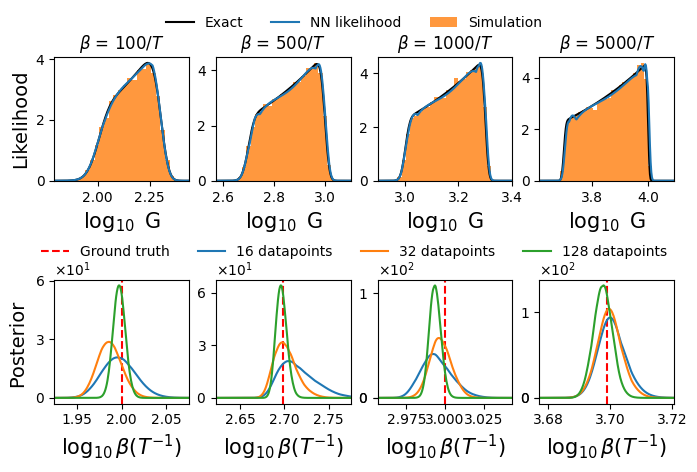

In [9]:

# Then use:
fig = make_double_panel(model, target)
plt.savefig('panelbc.png', dpi=600)
